In [20]:
import numpy as np

import numpy as np

class DiscountEnv:

    def __init__(self,
                 discounts,
                 avg_buyers,
                 brand_cost,
                 base_price=100.0,
                 seed=0):

        self.discounts = np.asarray(discounts)
        self.avg_buyers = np.asarray(avg_buyers)
        self.brand_cost = np.asarray(brand_cost)
        self.price = base_price

        self.rng = np.random.default_rng(seed)

        # normalization constant
        self.R_max = self.price * (1 - np.min(self.discounts)) * np.max(self.avg_buyers)

    def step(self, a):

        buyers = self.rng.poisson(self.avg_buyers[a])

        raw_revenue = self.price * (1 - self.discounts[a]) * buyers

        # normalized reward in [0,1] (approximately)
        reward = raw_revenue / self.R_max

        cost = self.brand_cost[a]

        return reward, cost

def make_sale_clearance_environment(ndim=5,seed=432):
  discounts = [0.05, 0.10, 0.15, 0.20, 0.25]
  avg_buyers = [8, 12, 16, 18, 17]
  brand_cost = [0.1, 0.2, 0.35, 0.65, 0.9]

  env = DiscountEnv(discounts, avg_buyers, brand_cost=brand_cost)
  return env

In [28]:
import numpy as np
from tqdm import tqdm
class constrained_KL_reg:
    def __init__(self,beta_r,beta_g,lambda_,tau,rho,kappa,K,nA,actions,b,env):
        self.beta_r = beta_r
        self.beta_g = beta_g
        self.lambda_ = lambda_
        self.tau = tau
        self.rho = rho
        self.kappa = kappa
        self.K = K
        #self.a = a
        self.nA = nA
        self.actions = actions
        self.pi_ref = np.ones(self.nA)/self.nA
        self.b = b
        self.env = env
    def onehot(self,a):
        one_hot = np.zeros(self.nA)
        one_hot[a] = 1
        return one_hot
    def special_initialization(self,init_policy=None,Lambda = None,thetar=None,thetag=None):
        if(init_policy==None):
            self.pi = np.ones(self.nA)/self.nA
        else:
            self.pi = init_policy

        if(Lambda==None):
            self.Lambda = self.rho*np.eye(self.nA) #need size here
        else:
            self.Lambda = Lambda
    def calculate_theta(self,a,j):
        a = np.array(a)
        lam_inv = np.linalg.inv(self.Lambda)
        add = np.zeros(len(a[0]))
        for i in range(len(a)):
            add = add + a[i]*j[i]  ###Confirm will it be reward/cost value of theta itself?
        return np.matmul(lam_inv,add)
    def update_policy(self,g_hat,r_hat):
        g_expect = np.sum([self.pi[i]*g_hat[i] for i in range(self.nA)])
        z = (self.b - g_expect)/self.tau
        exp_term = np.exp((r_hat-self.kappa+self.lambda_*self.tau*g_hat/(1+np.exp(-z)))*1/self.kappa)#Cheeck this term
        pi_new = self.pi_ref*exp_term #Check this term
        pi_new = pi_new/np.sum(pi_new)
        return pi_new
    def run_algo(self):
        action_arr = []
        actions = []
        rew_arr = []
        utility_arr = []
        for k in tqdm(range(self.K)):
            #print(k,"=>",self.pi)
            ak = self.actions[np.random.choice(self.nA,p=self.pi)]
            action_arr.append(self.onehot(ak))
            actions.append(ak)
            rew,cost = env.step(ak)
            rew_arr.append(rew)
            utility_arr.append(-cost)
            theta_r,theta_g = self.calculate_theta(action_arr,rew_arr),self.calculate_theta(action_arr,utility_arr)
            r_hat = []
            g_hat = []
            for a in self.actions:
                r_hat.append(np.dot(self.onehot(a),theta_r)+self.beta_r*np.sqrt(np.dot(np.transpose(self.onehot(a)),np.dot(np.linalg.inv(self.Lambda),self.onehot(a)))))
                g_hat.append(np.dot(self.onehot(a),theta_g)+self.beta_g*np.sqrt(np.dot(np.transpose(self.onehot(a)),np.dot(np.linalg.inv(self.Lambda),self.onehot(a)))))
            #rew_arr.append(r_hat,g_hat)
            #print("R_hat and g_hat:",r_hat,g_hat)
            self.pi = self.update_policy(g_hat,r_hat)
            self.Lambda = self.Lambda + np.matmul(self.onehot(ak),np.transpose(self.onehot(ak)))
        return actions,rew_arr,utility_arr

In [ ]:
import pandas as pd
import pickle
if __name__ == "__main__":

    # constraint threshold b
    b = -0.60
    ndim = 5

    # Build environment objects compatible with R[ak], U[ak]
    env = make_sale_clearance_environment(ndim)
    nA = ndim
    actions = np.arange(ndim)

    # Create  agent
    agent = constrained_KL_reg(
        beta_r=2.0,
        beta_g=2.0,
        lambda_=15.0,
        tau=0.3,
        rho=0.4,
        kappa=5,
        K=10000,
        nA=nA,
        actions=actions,
        b=b,
        env=env
    )#beta_r,beta_g,lambda_,tau,rho,kappa,K,nA,actions,b,env

    agent.special_initialization()

    _orig_update_policy = agent.update_policy
    def _wrapped_update_policy(g_hat, r_hat):
        return _orig_update_policy(np.asarray(g_hat, dtype=float), np.asarray(r_hat, dtype=float))
    agent.update_policy = _wrapped_update_policy

    # Run
    actions,rew_arr,utility_arr = agent.run_algo()
    dict_ = {'reward':rew_arr,'utility':utility_arr}
    df = pd.DataFrame(dict_)
    df.to_excel('Sale_clearance_our_algo_try.xlsx')

    print("Run finished.")
    print("Final pi:", np.round(agent.pi, 4))
    print("Final Lambda (shape):", agent.Lambda.shape)

 94%|█████████▍| 9447/10000 [04:01<00:25, 21.63it/s]

In [33]:
from collections import Counter
Counter(actions)

Counter({np.int64(4): 15,
         np.int64(2): 1146,
         np.int64(3): 24,
         np.int64(0): 8641,
         np.int64(1): 174})

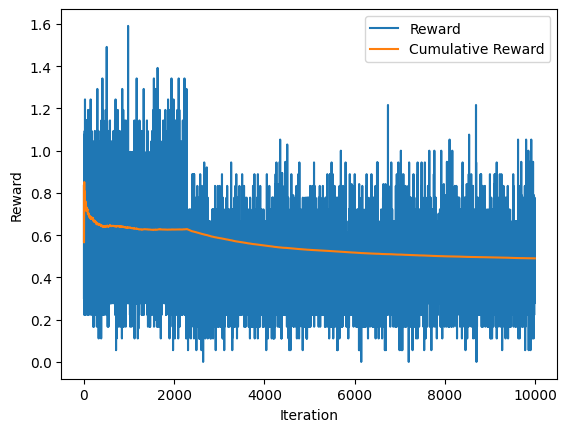

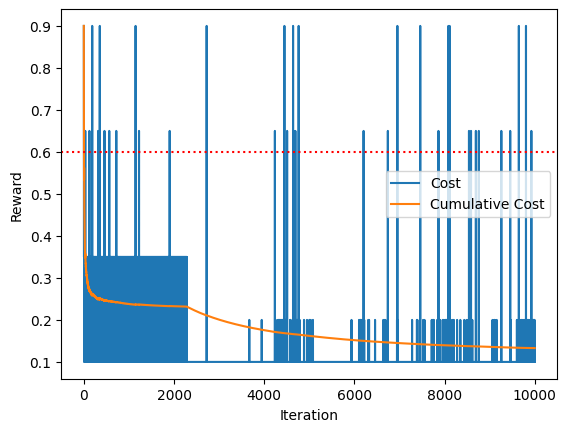

In [34]:
from matplotlib import pyplot as plt
plt.figure()
plt.plot(rew_arr)
plt.plot(np.cumsum(rew_arr)/np.arange(1,len(rew_arr)+1))
plt.legend(['Reward','Cumulative Reward'])
plt.xlabel('Iteration')
plt.ylabel('Reward')
plt.show()

plt.figure()
plt.plot(-np.array(utility_arr))
plt.plot(-np.cumsum(utility_arr)/np.arange(1,len(utility_arr)+1))
plt.axhline(y=-b,linestyle=":",color="red")
plt.legend(['Cost','Cumulative Cost'])
plt.xlabel('Iteration')
plt.ylabel('Reward')
plt.show()

In [38]:
import numpy as np

class TabularPrimalDualLinUCB:
    def __init__(self, env, b,ndim,
                 beta_r=1.0, beta_g=1.0,
                 rho=1.0, eta=0.05, K=500):

        self.env = env
        self.nA = ndim
        self.b = b

        self.beta_r = beta_r
        self.beta_g = beta_g
        self.rho = rho
        self.eta = eta
        self.K = K

        self.N = np.zeros(self.nA)   # action counts
        self.lambda_dual = 0

    def bonus(self, a):
        return 1.0 / np.sqrt(self.N[a] + self.rho)

    def select_action(self):
        values = []
        for a in range(self.nA):
            rew,cost = self.env.step(a)
            val = (
                rew
                + self.beta_r * self.bonus(a)
                - self.lambda_dual * (
                    cost
                    + self.beta_g * self.bonus(a)
                    - self.b
                )
            )
            values.append(val)
        #print(values)
        #input()
        return int(np.argmax(values))

    def run_algo(self):
        actions, rewards, costs, lambdas = [], [], [], []

        for _ in range(self.K):
            if _ < self.nA:
                a = _
            else:
              a = self.select_action()
            #print(a)
            r,g = self.env.step(a)
            #print("Action selected:",a)
            #print("Cost returned:",g)
            #print("Raw output:",self.G[a])
            #input()

            actions.append(a)
            rewards.append(r)
            costs.append(g)
            lambdas.append(self.lambda_dual)

            self.N[a] += 1
            self.lambda_dual = max(
                0.0,
                self.lambda_dual + self.eta * (g - self.b)
            )

        return actions, rewards, costs, lambdas

In [39]:
from collections import Counter

# constraint threshold b
b = 0.60

# Build environment objects compatible with R[ak], U[ak]
ndim = 5
env = make_sale_clearance_environment(ndim)
#nA = actions.shape[0]

beta_r=1.0
beta_g=1.0
lambda_=20.0
tau=1.0
rho=1e-8
kappa=30.0
a=None
actions=actions
K=10000
eta = 0.05
is_tab = 1
#env, b,ndim,beta_r=1.0, beta_g=1.0,rho=1.0, eta=0.05, K=500
agent=TabularPrimalDualLinUCB(env,b,ndim,beta_r,beta_g,rho,eta,K)
actions, rew_arr,util_arr,lambdas = agent.run_algo()

import pandas as pd
dict_ = {'reward':rew_arr,'utility':util_arr}
df = pd.DataFrame(dict_)
df.to_excel('Sale_clearance_Lin_UCB.xlsx')

import pickle
with open('Case1_constrained_Lin_UCB_3_arms_actions.pkl', 'wb') as f:
    pickle.dump(actions, f)
f.close()

with open('Case1_constrained_Lin_UCB_3_arms_lambdas.pkl', 'wb') as f:
    pickle.dump(lambdas, f)
f.close()
print(Counter(actions))

Counter({3: 3807, 2: 2983, 4: 1942, 1: 1045, 0: 223})


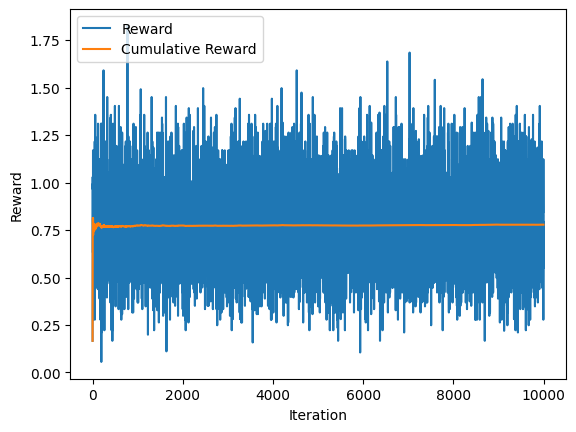

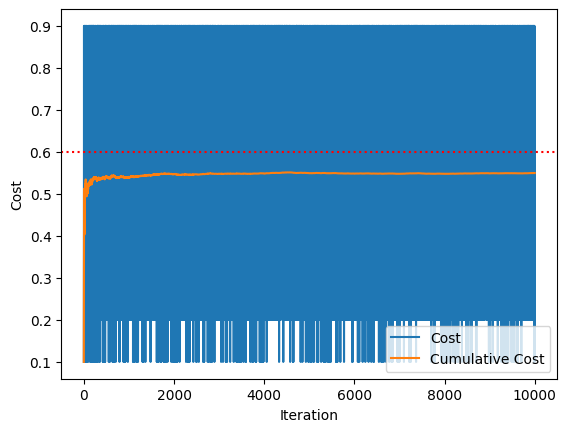

In [40]:
plt.figure()
plt.plot(rew_arr)
plt.plot(np.cumsum(rew_arr)/np.arange(1,len(rew_arr)+1))
plt.legend(['Reward','Cumulative Reward'])
plt.xlabel('Iteration')
plt.ylabel('Reward')
plt.show()

plt.figure()
plt.plot(np.array(util_arr))
plt.plot(np.cumsum(util_arr)/np.arange(1,len(util_arr)+1))
plt.axhline(y=b,linestyle=":",color="red")
plt.legend(['Cost','Cumulative Cost'])
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.show()

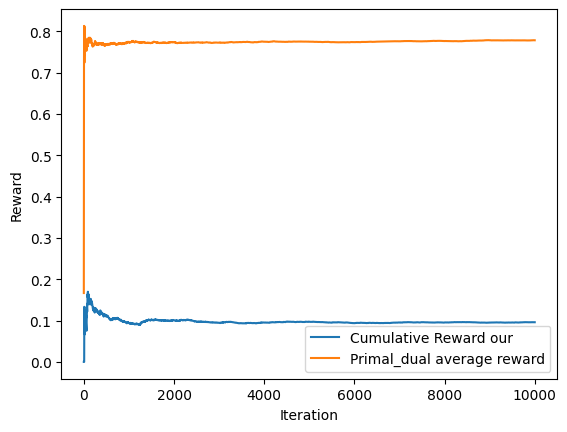

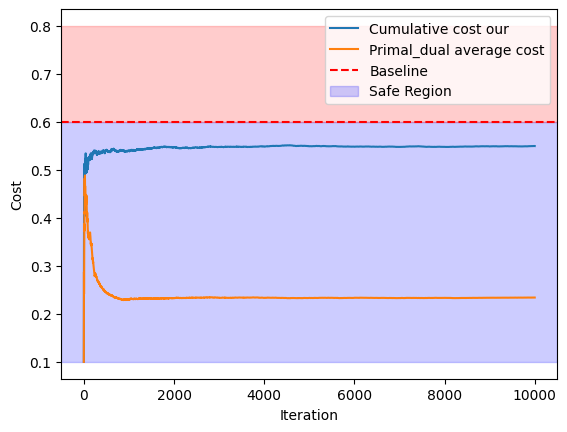

In [42]:
path = "/content/Sale_clearance_our_algo.xlsx"
import pandas as pd
df = pd.read_excel(path)
reward = df['reward'].values
cost = df['utility'].values

plt.figure()
#plt.plot(reward)
plt.plot(np.cumsum(reward)/np.arange(1,len(reward)+1))
plt.plot(np.cumsum(rew_arr)/np.arange(1,len(rew_arr)+1))
#plt.plot(rew_arr)
plt.legend(['Cumulative Reward our','Primal_dual average reward'])
plt.xlabel('Iteration')
plt.ylabel('Reward')
#plt.savefig('Sale_clearance_experiment_expected reward comparison.pdf')
plt.show()

plt.figure()
#plt.plot(-cost)
plt.plot(np.cumsum(util_arr)/np.arange(1,len(util_arr)+1))
plt.plot(-np.cumsum(cost)/np.arange(1,len(cost)+1))
#plt.plot(util_arr)
plt.axhline(y=0.6,linestyle='--',color='red')
plt.axhspan(0.1,b,color='blue',alpha=0.2)
plt.axhspan(b,0.8,color='red',alpha=0.2)
plt.legend(['Cumulative cost our','Primal_dual average cost','Baseline','Safe Region'])
plt.xlabel('Iteration')
plt.ylabel('Cost')
#plt.savefig('Sale_clearance_average_cost_comparison.pdf')
plt.show()